🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...
1. Đang tải và ép cân dữ liệu Calendar...
2. Đang tải dữ liệu Sales...
3. Đang Melt (kéo giãn) dữ liệu Sales...
4. Đang Merge Sales với Calendar...

-> Đang xử lý Outliers (IQR) và Zeroes...
5. Ép cân lần cuối cho DataFrame tổng...
-> Đang load dữ liệu Giá (sell_prices.csv)...
-> Đang hợp nhất và tính toán độ co giãn giá...
-> Đang xử lý Sự kiện lễ tết (Calendar Events)...
-> Đang tạo Đặc trưng Thời gian (Time Features)...

🛠️ Đang gom dữ liệu theo TUẦN để giảm biến động...
🛠️ Đang chế tạo Siêu Đặc trưng TUẦN...

🧠 Đang huấn luyện AI dự báo TUẦN...
✅ Huấn luyện AI hoàn tất!

📊 SAI SỐ TUẦN (MÔ HÌNH TRẦM TÍNH): MAE = 4.07 | RMSE = 9.22

🎯 Trích xuất dự báo và chạy Mô phỏng Tồn kho cho món hàng: 0

📊 BÁO CÁO SAI SỐ (MÔ HÌNH TUẦN) - MÃ 0 📊
CHIẾN LƯỢC NHẬP KHO: ROP = 0 | EOQ = 15
TỔNG CHI PHÍ DỰ KIẾN: $162.00
SAI SỐ TUẦN CỤ THỂ: MAE = 2.75 | RMSE = 3.34


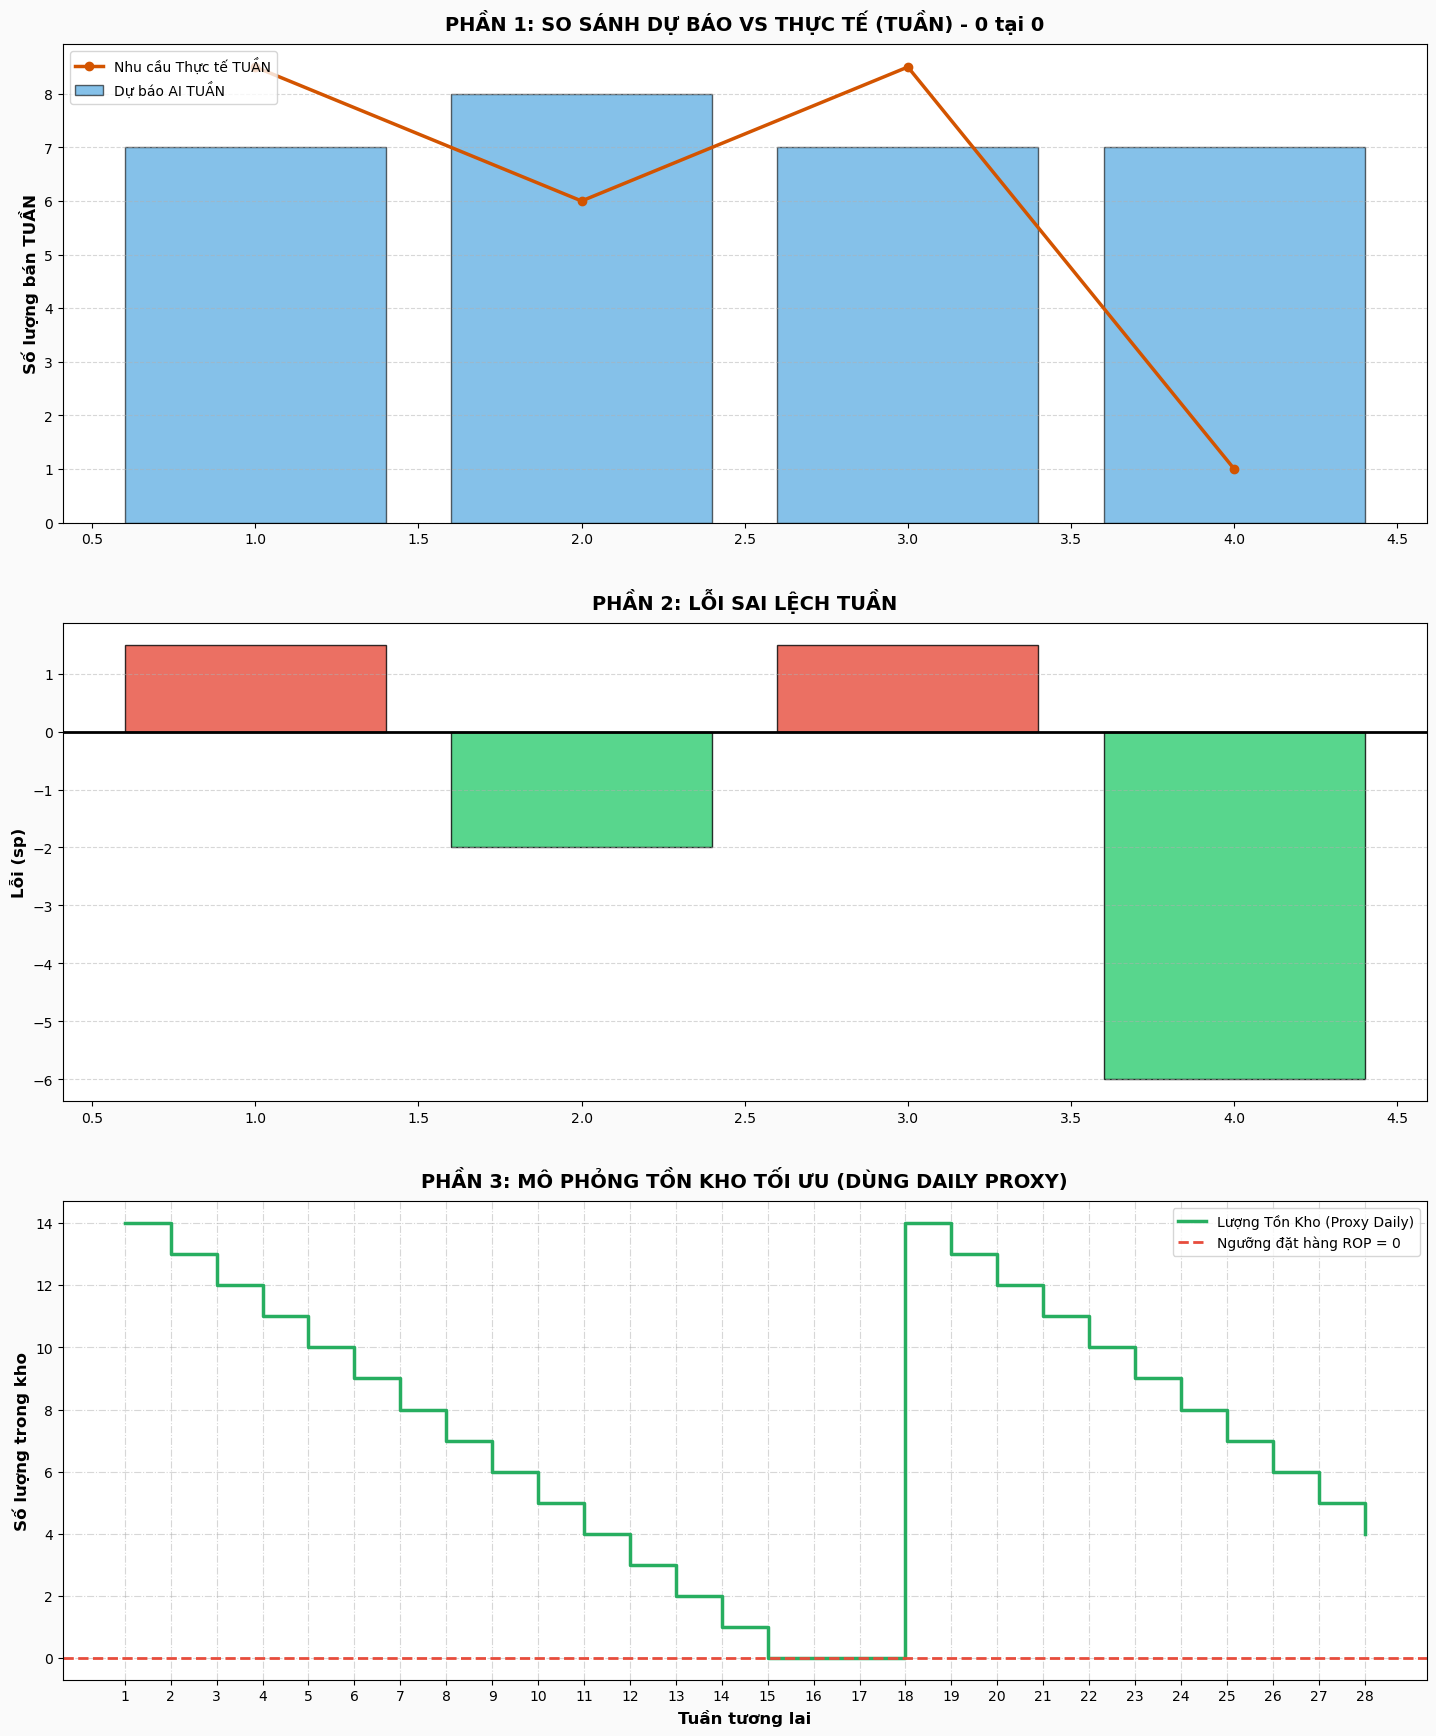

In [3]:
import sys
import os
import numpy as np
import pandas as pd
import lightgbm as lgb
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

sys.path.append(os.path.abspath('../src'))
from dataPreprocessing import load_and_preprocess_raw
from featureEngineering import generate_all_features

RAW_DIR = '../dataset/raw/'

# ==========================================
# BƯỚC 1 & 2: TIỀN XỬ LÝ (Lấy nhiều dữ liệu hơn)
# ==========================================
print("🚀 BẮT ĐẦU CHẠY PIPELINE DỮ LIỆU...")
# Lấy 200,000 dòng để AI có đủ dữ liệu học chéo các mặt hàng và chu kỳ tuần
df_master = load_and_preprocess_raw(RAW_DIR, nrows=200000)
df_featured = generate_all_features(df_master, RAW_DIR)

# Lọc nguyên 1 store để demo cho nhanh (VD: CA_1)
sample_store = df_featured['store_id'].unique()[0]
df_store = df_featured[df_featured['store_id'] == sample_store].copy()

# ==========================================
# [MỚI] BƯỚC 3: GOM DỮ LIỆU THEO TUẦN (WEEKLY AGGREGATION) 
# ==========================================
print("\n🛠️ Đang gom dữ liệu theo TUẦN để giảm biến động...")
# Gom doanh số, giá, discount theo TUẦN (wm_yr_wk)
agg_dict = {
    'demand': 'sum', # Tổng doanh số tuần
    'sell_price': 'mean', # Giá trung bình tuần
    'price_discount': 'mean', # Discount trung bình tuần
    'price_momentum': 'mean', # Momentum trung bình tuần
}

# Gom sự kiện trong ngày lại thành một cờ hiệu tuần (Ví dụ: Tuần này có ngày lễ không?)
df_store['has_event_wk'] = df_store['event_name_1'].apply(lambda x: 1 if pd.notna(x) else 0)
agg_dict['has_event_wk'] = 'max' # Nếu bất kỳ ngày nào có lễ, tuần đó có lễ

# Gom dữ liệu bằng wm_yr_wk
df_weekly = df_store.groupby(['item_id', 'store_id', 'wm_yr_wk']).agg(agg_dict).reset_index()

# Thêm Date Features tuần
df_weekly['week_of_year'] = (df_weekly['wm_yr_wk'] % 100).astype('category')
df_weekly['year'] = (df_weekly['wm_yr_wk'] // 100).astype('category')

# ==========================================
# [MỚI] BƯỚC 4: CHẾ TẠO SIÊU ĐẶC TRƯNG TUẦN (WEEKLY FEATURES)
# ==========================================
print("🛠️ Đang chế tạo Siêu Đặc trưng TUẦN...")
df_weekly = df_weekly.sort_values(['item_id', 'wm_yr_wk'])

# Tính Lag và Rolling theo tuần
lags_wk = [1, 2, 4] # Doanh số 1 tuần trước, 2 tuần trước, 4 tuần trước
for lag in lags_wk:
    df_weekly[f'lag_{lag}_wk'] = df_weekly.groupby('item_id')['demand'].shift(lag)

wins_wk = [4] # Trung bình sales 4 tuần qua
for win in wins_wk:
    df_weekly[f'rmean_{win}_wk'] = df_weekly.groupby('item_id')['demand'].transform(lambda x: x.shift(1).rolling(win).mean())

df_weekly = df_weekly.dropna()

# Chuyển format
df_weekly['item_id'] = df_weekly['item_id'].astype('category')
df_weekly['has_event_wk'] = df_weekly['has_event_wk'].astype('category')

features = [
    'item_id', 'sell_price', 'price_discount', 'price_momentum', 
    'has_event_wk', 'week_of_year', 'year', 'lag_1_wk', 'lag_2_wk', 'lag_4_wk', 'rmean_4_wk'
]
target = 'demand'

# Tách Train/Test (28 ngày cuối làm Test, tức là khoảng 4 tuần)
max_week = df_weekly['wm_yr_wk'].max()
split_week = max_week - 4 # Reserve 4 tuần cuối

train_data_weekly = df_weekly[df_weekly['wm_yr_wk'] <= split_week]
test_data_weekly = df_weekly[df_weekly['wm_yr_wk'] > split_week]

X_train, y_train = train_data_weekly[features], train_data_weekly[target]
X_test_weekly, y_test_weekly = test_data_weekly[features], test_data_weekly[target]

# ==========================================
# BƯỚC 5: HUẤN LUYỆN MODEL "TRẦM TÍNH" (Regression)
# ==========================================
print("\n🧠 Đang huấn luyện AI dự báo TUẦN...")
params = {
    'objective': 'regression', # Regression học chu kỳ mượt mà hơn
    'metric': 'rmse',
    'learning_rate': 0.05,
    'num_leaves': 63, # Não bộ sâu
    'verbose': -1,
    'force_col_wise': True
}

cat_feats = ['item_id', 'has_event_wk', 'week_of_year', 'year']
train_set = lgb.Dataset(X_train, y_train, categorical_feature=cat_feats)

# Học 200 vòng để model hội tụ
model = lgb.train(params, train_set, num_boost_round=200) 
print("✅ Huấn luyện AI hoàn tất!")

# ==========================================
# BƯỚC 5B: ĐÁNH GIÁ SAI SỐ TUẦN
# ==========================================
# AI dự báo và làm tròn
weekly_forecast = model.predict(X_test_weekly)
weekly_forecast = np.round(weekly_forecast).astype(int)

mae_weekly = mean_absolute_error(y_test_weekly, weekly_forecast)
rmse_weekly = np.sqrt(mean_squared_error(y_test_weekly, weekly_forecast))
print(f"\n📊 SAI SỐ TUẦN (MÔ HÌNH TRẦM TÍNH): MAE = {mae_weekly:,.2f} | RMSE = {rmse_weekly:,.2f}")

# ==========================================
# BƯỚC 6: CHỌN MÃ 1437 ĐỂ VẼ BIỂU ĐỒ 
# ==========================================
# Chọn món hàng ban đầu của bạn làm mẫu
selected_item = df_weekly['item_id'].unique()[0]
print(f"\n🎯 Trích xuất dự báo và chạy Mô phỏng Tồn kho cho món hàng: {selected_item}")

df_target_weekly = df_weekly[(df_weekly['item_id'] == selected_item) & (df_weekly['wm_yr_wk'] > split_week)].copy()
X_target_weekly = df_target_weekly[features]
y_target_weekly_actual = df_target_weekly[target].values

# AI dự báo và làm tròn cho món Smooth mục tiêu
weekly_forecast_target = model.predict(X_target_weekly)
weekly_forecast_target = np.maximum(0, np.round(weekly_forecast_target)).astype(int)

# ⚠️ CHUYỂN ĐỔI TUẦN SANG NGÀY ĐỂ MÔ PHỎNG TỒN KHO ⚠️
daily_demand_proxy = np.round(weekly_forecast_target / 7).astype(int)
daily_demand_forecast = np.repeat(daily_demand_proxy, 7)[:28] # Proxy daily

# Mô phỏng Tồn kho
LEAD_TIME = 3            
ORDERING_COST = 50.0     
HOLDING_COST = 0.5       
STOCKOUT_COST = 5.0      
INITIAL_INVENTORY = 15   

def simulate_inventory(demand_array, ROP, Q):
    inventory = INITIAL_INVENTORY
    total_cost = 0
    days_to_arrival = 0
    order_placed = False
    inventory_history = []
    for demand in demand_array:
        if order_placed and days_to_arrival == 0:
            inventory += Q
            order_placed = False
        if inventory >= demand:
            inventory -= demand
        else:
            total_cost += (demand - inventory) * STOCKOUT_COST
            inventory = 0
        total_cost += inventory * HOLDING_COST
        if inventory <= ROP and not order_placed:
            total_cost += ORDERING_COST
            order_placed = True
            days_to_arrival = LEAD_TIME
        if order_placed:
            days_to_arrival -= 1
        inventory_history.append(inventory)
    return total_cost, inventory_history

best_cost, best_ROP, best_Q = float('inf'), 0, 0
best_history = []

for rop in range(0, 50, 2):
    for q in range(10, 150, 5):
        cost, history = simulate_inventory(daily_demand_forecast, rop, q)
        if cost < best_cost:
            best_cost, best_ROP, best_Q, best_history = cost, rop, q, history

# ==========================================
# VẼ BIỂU ĐỒ 3 TẦNG VÀ LƯU ẢNH (Dùng trục x TUẦN)
# ==========================================
print("\n" + "="*60)
print(f"📊 BÁO CÁO SAI SỐ (MÔ HÌNH TUẦN) - MÃ {selected_item} 📊")
print("="*60)
print(f"CHIẾN LƯỢC NHẬP KHO: ROP = {best_ROP} | EOQ = {best_Q}")
print(f"TỔNG CHI PHÍ DỰ KIẾN: ${best_cost:,.2f}")

num_test_weeks = len(y_target_weekly_actual)
plot_horizon = range(1, num_test_weeks + 1)

# Tính lại sai số TUẦN để in báo cáo chính xác
mae_target_weekly = mean_absolute_error(y_target_weekly_actual, weekly_forecast_target)
rmse_target_weekly = np.sqrt(mean_squared_error(y_target_weekly_actual, weekly_forecast_target))
print(f"SAI SỐ TUẦN CỤ THỂ: MAE = {mae_target_weekly:,.2f} | RMSE = {rmse_target_weekly:,.2f}")

daily_errors_weekly_proxy = y_target_weekly_actual - weekly_forecast_target

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 18), facecolor='#FAFAFA')

ax1.bar(plot_horizon, weekly_forecast_target, color='#3498DB', edgecolor='black', alpha=0.6, label='Dự báo AI TUẦN')
ax1.plot(plot_horizon, y_target_weekly_actual, color='#D35400', marker='o', linewidth=2.5, label='Nhu cầu Thực tế TUẦN')
ax1.set_title(f"PHẦN 1: SO SÁNH DỰ BÁO VS THỰC TẾ (TUẦN) - {selected_item} tại {sample_store}", fontsize=14, fontweight='bold', pad=10) 
ax1.set_ylabel("Số lượng bán TUẦN", fontsize=12, fontweight='bold')
ax1.grid(axis='y', linestyle='--', alpha=0.5)
ax1.legend(loc='upper left')

colors = ['#E74C3C' if e > 0 else '#2ECC71' for e in daily_errors_weekly_proxy]
ax2.bar(plot_horizon, daily_errors_weekly_proxy, color=colors, edgecolor='black', alpha=0.8)
ax2.axhline(y=0, color='black', linestyle='-', linewidth=2)
ax2.set_title(f"PHẦN 2: LỖI SAI LỆCH TUẦN", fontsize=14, fontweight='bold', pad=10)
ax2.set_ylabel("Lỗi (sp)", fontsize=12, fontweight='bold')
ax2.grid(axis='y', linestyle='--', alpha=0.5)

ax3.step(range(1, 29), best_history, where='post', color='#27AE60', linewidth=2.5, label='Lượng Tồn Kho (Proxy Daily)')
ax3.axhline(y=best_ROP, color='#E74C3C', linestyle='--', linewidth=2, label=f'Ngưỡng đặt hàng ROP = {best_ROP}')
ax3.set_title(f"PHẦN 3: MÔ PHỎNG TỒN KHO TỐI ƯU (DÙNG DAILY PROXY)", fontsize=14, fontweight='bold', pad=10)
ax3.set_xlabel("Tuần tương lai", fontsize=12, fontweight='bold')
ax3.set_ylabel("Số lượng trong kho", fontsize=12, fontweight='bold')
ax3.set_xticks(range(1, 29))
ax3.grid(True, linestyle='-.', alpha=0.5)
ax3.legend(loc='upper right')

plt.tight_layout(pad=3.0) 
os.makedirs('../docs/images', exist_ok=True)
plt.savefig('../docs/images/bieu_do_smooth_weekly.png', dpi=300, bbox_inches='tight')
plt.show()